In [15]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import warnings

warnings.filterwarnings("ignore", category=UserWarning, module="torch_geometric")

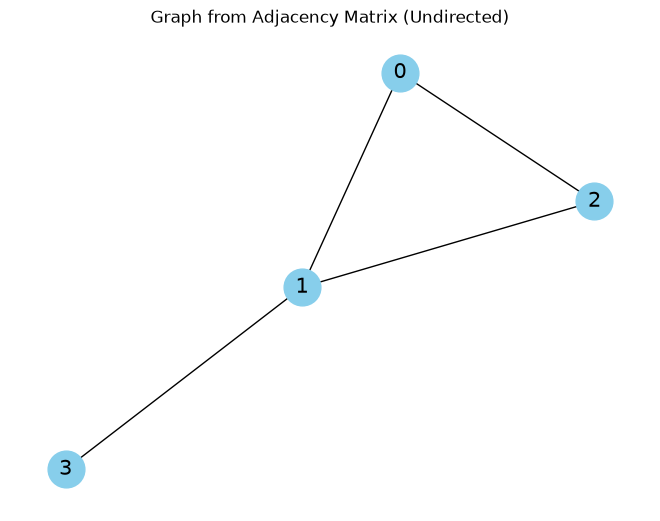

In [5]:
# Adjacency Matrix from Numpy
A = np.array([
    [0, 1, 1, 0],
    [1, 0, 1, 1],
    [1, 1, 0, 0],
    [0, 1, 0, 0]
])

# Create the Graph. The nodes will be labeled 0, 1, 2, 3
G = nx.from_numpy_array(A)

# 3. Visualize the graph
pos = nx.spring_layout(G)
nx.draw(
    G,
    pos, 
    with_labels=True,
    node_color='skyblue',
    node_size=700,
    edge_color='k',
    linewidths=1,
    font_size=15
    )
plt.title("Graph from Adjacency Matrix (Undirected)")
plt.show()

In [6]:
import torch
from torch_geometric.utils import (
    dense_to_sparse,
    to_dense_adj
)

A_np = np.array([
    [0, 1, 1, 0],
    [1, 0, 1, 1],
    [1, 1, 0, 0],
    [0, 1, 0, 0]
])

# Convertimos a Tensor de PyTorch (necesario para PyG)
A = torch.from_numpy(A_np)

print("="*40)
print(A)
print("="*40)

tensor([[0, 1, 1, 0],
        [1, 0, 1, 1],
        [1, 1, 0, 0],
        [0, 1, 0, 0]])


## Adyacencias en formato COO

Coordinate Format (COO) (https://docs.pytorch.org/docs/stable/sparse.html#sparse-coo-docs)

In [9]:
print("Adyacencias en formato COO")
# dense_to_sparse devuelve (edge_index, edge_attr)
edge_index, _ = dense_to_sparse(A)
print(edge_index)

Adyacencias en formato COO
tensor([[0, 0, 1, 1, 1, 2, 2, 3],
        [1, 2, 0, 2, 3, 0, 1, 1]])


## Reconstruimos la matriz densa de adyacencias

In [10]:
dense_adj = to_dense_adj(edge_index)
print(dense_adj)

tensor([[[0., 1., 1., 0.],
         [1., 0., 1., 1.],
         [1., 1., 0., 0.],
         [0., 1., 0., 0.]]])


## Features numericas de los nodos

In [40]:
df = pd.DataFrame(
    np.random.rand(4, 10),
    columns=[f'col_{i}' for i in range(10)]
    )

df

,col_0,col_1,col_2,col_3,col_4,col_5,col_6,col_7,col_8,col_9
0,0.031041,0.712455,0.714312,0.386906,0.444287,0.720381,0.969855,0.743212,0.141267,0.822572
1,0.632928,0.131034,0.776746,0.245298,0.625241,0.552666,0.616428,0.449782,0.213631,0.375819
2,0.439662,0.175105,0.581729,0.740357,0.657366,0.307517,0.714260,0.033666,0.449823,0.341484
3,0.420245,0.163702,0.555334,0.392554,0.717815,0.087866,0.922340,0.016983,0.747493,0.625162


In [43]:
df.to_numpy()

array([[0.03104052, 0.71245488, 0.71431235, 0.38690642, 0.44428665,
        0.72038063, 0.96985464, 0.74321186, 0.14126653, 0.82257236],
       [0.6329282 , 0.13103436, 0.77674584, 0.24529756, 0.62524132,
        0.55266633, 0.61642845, 0.44978156, 0.21363136, 0.37581947],
       [0.4396623 , 0.17510537, 0.58172946, 0.74035699, 0.657366  ,
        0.30751741, 0.71425952, 0.03366598, 0.44982255, 0.34148395],
       [0.4202452 , 0.16370238, 0.55533438, 0.39255397, 0.71781529,
        0.08786626, 0.92234006, 0.01698326, 0.7474931 , 0.62516152]])

In [46]:
x = torch.tensor(df.to_numpy(), dtype=torch.float)

x

tensor([[0.0310, 0.7125, 0.7143, 0.3869, 0.4443, 0.7204, 0.9699, 0.7432, 0.1413,
         0.8226],
        [0.6329, 0.1310, 0.7767, 0.2453, 0.6252, 0.5527, 0.6164, 0.4498, 0.2136,
         0.3758],
        [0.4397, 0.1751, 0.5817, 0.7404, 0.6574, 0.3075, 0.7143, 0.0337, 0.4498,
         0.3415],
        [0.4202, 0.1637, 0.5553, 0.3926, 0.7178, 0.0879, 0.9223, 0.0170, 0.7475,
         0.6252]])

## Representación de Features Numéricas + Adjacencias

In [47]:
data = Data(x=x, edge_index=edge_index)

In [48]:
data.x

tensor([[0.0310, 0.7125, 0.7143, 0.3869, 0.4443, 0.7204, 0.9699, 0.7432, 0.1413,
         0.8226],
        [0.6329, 0.1310, 0.7767, 0.2453, 0.6252, 0.5527, 0.6164, 0.4498, 0.2136,
         0.3758],
        [0.4397, 0.1751, 0.5817, 0.7404, 0.6574, 0.3075, 0.7143, 0.0337, 0.4498,
         0.3415],
        [0.4202, 0.1637, 0.5553, 0.3926, 0.7178, 0.0879, 0.9223, 0.0170, 0.7475,
         0.6252]])

In [50]:
data.edge_index

tensor([[0, 0, 1, 1, 1, 2, 2, 3],
        [1, 2, 0, 2, 3, 0, 1, 1]])